In [1]:
## 1. Importing Necessary Libraries and Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Load the dataset
print("--- Loading Dataset ---")
df = pd.read_csv('framingham.csv')

print("\nDataset Information:")
df.info()

print("\nFirst 5 rows of the dataset:")
print(df.head())


--- Loading Dataset ---

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9),

In [3]:
# Drop the unnecessary 'education' column
df.drop('education', axis=1, inplace=True)
print("\n'education' column dropped.")

# Rename columns
df.rename(columns={
    'male': 'is_male',
    'currentSmoker': 'is_current_smoker',
    'cigsPerDay': 'cigs_per_day',
    'BPMeds': 'on_bp_meds',
    'prevalentStroke': 'has_prevalent_stroke',
    'prevalentHyp': 'has_prevalent_hyp',
    'diabetes': 'has_diabetes',
    'totChol': 'total_cholesterol',
    'sysBP': 'systolic_bp',
    'diaBP': 'diastolic_bp',
    'BMI': 'bmi',
    'heartRate': 'heart_rate',
    'glucose': 'glucose',
    'TenYearCHD': 'ten_year_chd'
}, inplace=True)

print("\nColumns renamed.")
print(df.head())



'education' column dropped.

Columns renamed.
   is_male  age  is_current_smoker  cigs_per_day  on_bp_meds  \
0        1   39                  0           0.0         0.0   
1        0   46                  0           0.0         0.0   
2        1   48                  1          20.0         0.0   
3        0   61                  1          30.0         0.0   
4        0   46                  1          23.0         0.0   

   has_prevalent_stroke  has_prevalent_hyp  has_diabetes  total_cholesterol  \
0                     0                  0             0              195.0   
1                     0                  0             0              250.0   
2                     0                  0             0              245.0   
3                     0                  1             0              225.0   
4                     0                  0             0              285.0   

   systolic_bp  diastolic_bp    bmi  heart_rate  glucose  ten_year_chd  
0        106.0      

In [5]:
## 2. Data Preprocessing

print("\n--- Data Preprocessing ---")
print(f"Rows before NaN removal: {len(df)}")
df.dropna(inplace=True)
print(f"Rows after NaN removal: {len(df)}")

df.reset_index(drop=True, inplace=True)

# Split features & target
X = df.drop('ten_year_chd', axis=1)
y = df['ten_year_chd']

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nDataset split:")
print(f"Train: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete.")



--- Data Preprocessing ---
Rows before NaN removal: 4240
Rows after NaN removal: 3751

Dataset split:
Train: 2625 rows
Test:  1126 rows

Scaling complete.



--- EDA ---


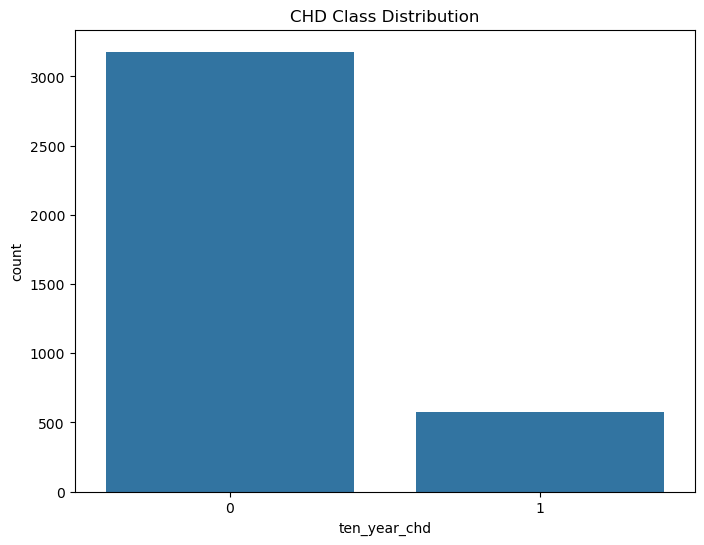

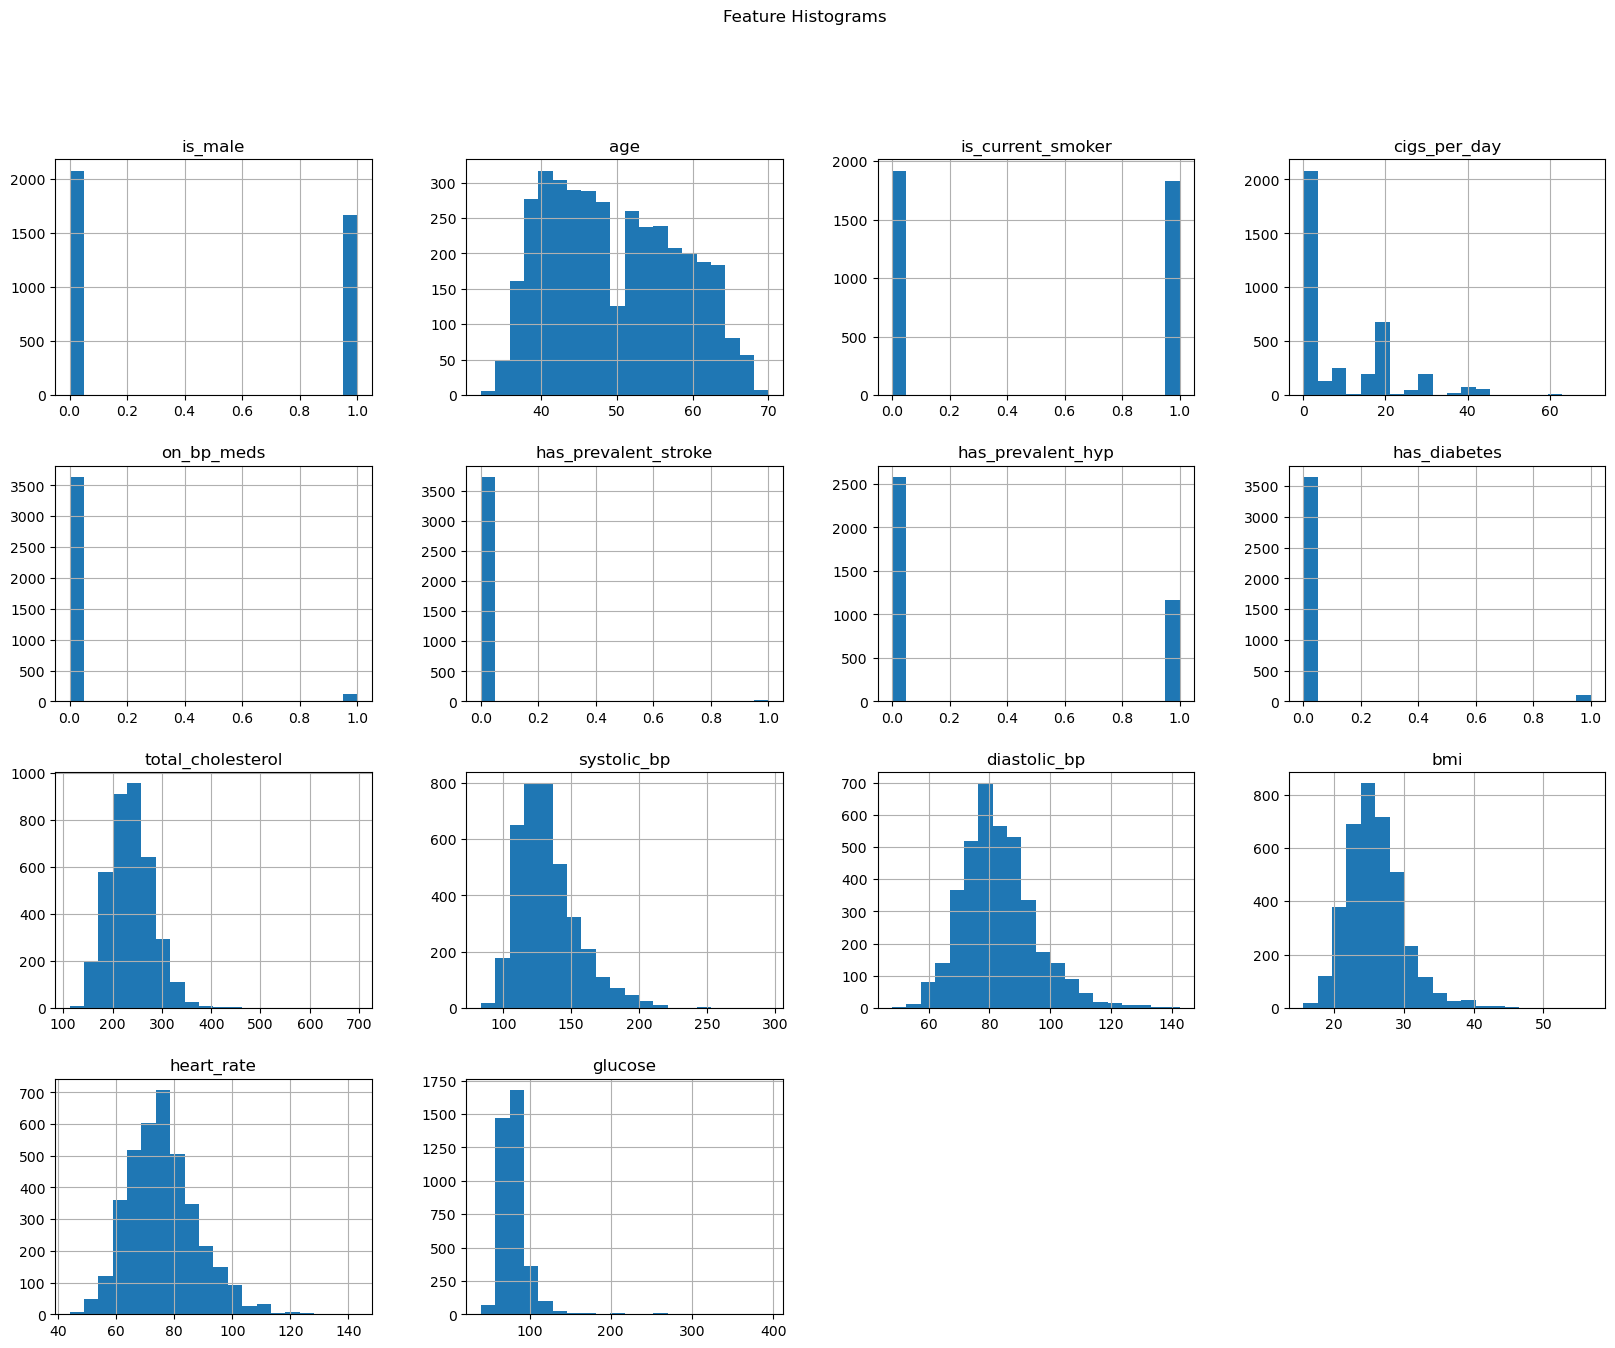

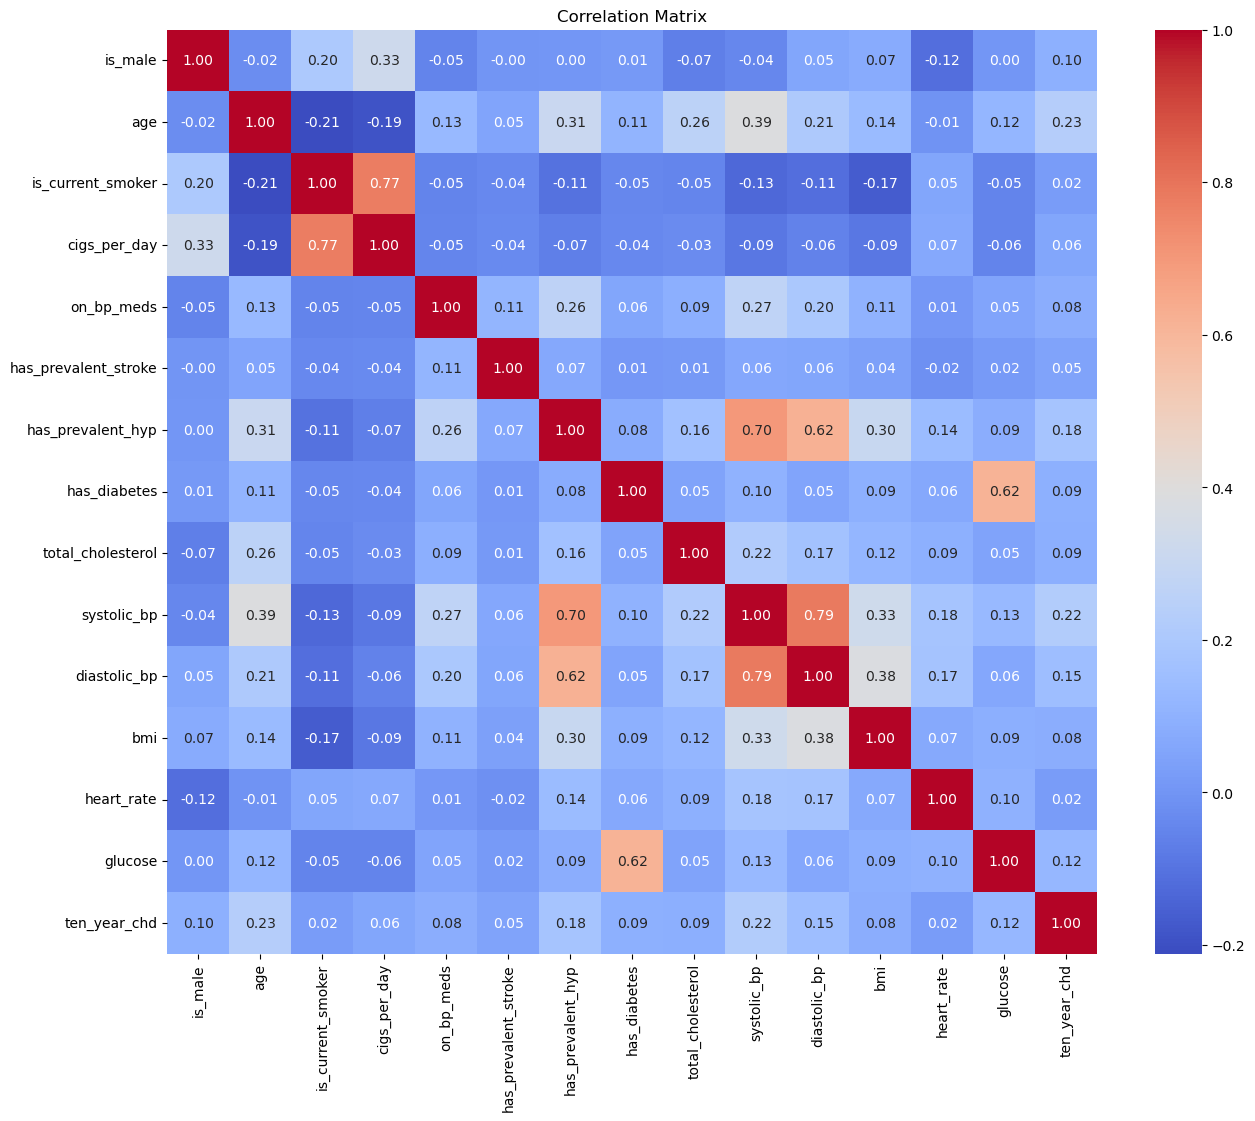

In [7]:
## 3. Exploratory Data Analysis (EDA)

print("\n--- EDA ---")

# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='ten_year_chd', data=df)
plt.title('CHD Class Distribution')
plt.show()

# Histograms for each feature
X.hist(figsize=(20, 15), bins=20)
plt.suptitle('Feature Histograms')
plt.show()

# Correlation heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [9]:
## 4. Model Training

print("\n--- Model Training ---")

log_reg = LogisticRegression(max_iter=1000, random_state=42)

print("Training model...")
log_reg.fit(X_train_scaled, y_train)

print("Training complete.")



--- Model Training ---
Training model...
Training complete.



--- Model Evaluation ---

Accuracy: 0.8339

Confusion Matrix:
[[926  12]
 [175  13]]


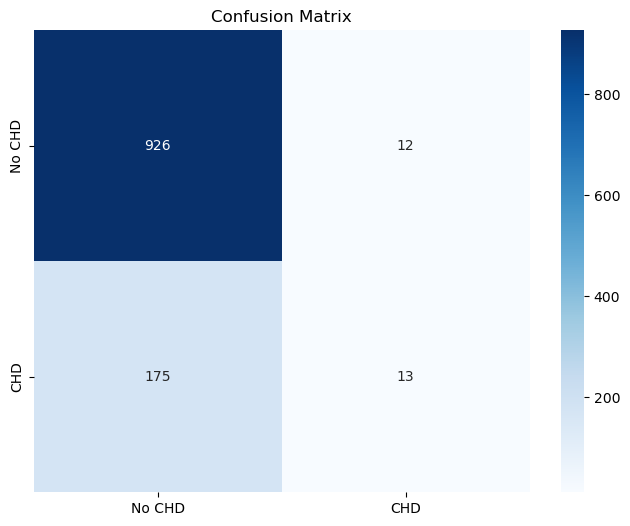


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.52      0.07      0.12       188

    accuracy                           0.83      1126
   macro avg       0.68      0.53      0.52      1126
weighted avg       0.79      0.83      0.78      1126



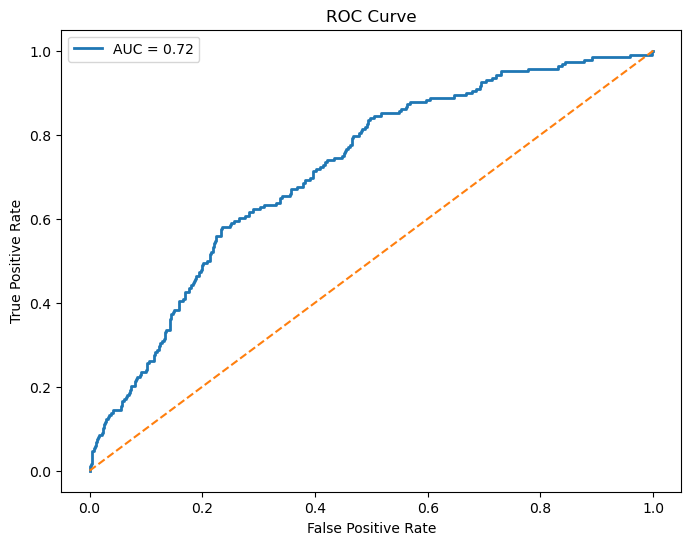

ROC AUC Score: 0.7171


In [11]:
## 5. Model Evaluation

print("\n--- Model Evaluation ---")

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD', 'CHD'],
            yticklabels=['No CHD', 'CHD'])
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


In [13]:
## 6. Predicting CHD for New Patient

new_patient_data = pd.DataFrame({
    'is_male': [1],
    'age': [55],
    'is_current_smoker': [1],
    'cigs_per_day': [20],
    'on_bp_meds': [0],
    'has_prevalent_stroke': [0],
    'has_prevalent_hyp': [1],
    'has_diabetes': [0],
    'total_cholesterol': [250],
    'systolic_bp': [160],
    'diastolic_bp': [95],
    'bmi': [31.5],
    'heart_rate': [80],
    'glucose': [85]
})

print("\nNew Patient Data:")
print(new_patient_data)

# Scale new data
new_scaled = scaler.transform(new_patient_data)

# Predict
prediction = log_reg.predict(new_scaled)[0]
proba = log_reg.predict_proba(new_scaled)[0]

print(f"\nPrediction (0=No CHD, 1=CHD): {prediction}")
print(f"Prediction Probability: {proba}")
print(f"Heart Disease Likelihood: {proba[1] * 100:.2f}%")



New Patient Data:
   is_male  age  is_current_smoker  cigs_per_day  on_bp_meds  \
0        1   55                  1            20           0   

   has_prevalent_stroke  has_prevalent_hyp  has_diabetes  total_cholesterol  \
0                     0                  1             0                250   

   systolic_bp  diastolic_bp   bmi  heart_rate  glucose  
0          160            95  31.5          80       85  

Prediction (0=No CHD, 1=CHD): 0
Prediction Probability: [0.61631386 0.38368614]
Heart Disease Likelihood: 38.37%
